# **Data Pre porcessing**
*   Convert BMP to JPG and rescale images

In [ ]:
!pip -q install opencv-python scikit-image scikit-learn tqdm
import os, re, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import cv2


In [ ]:
IMG_ROOT = "/content/drive/MyDrive/Research data/sampledata_jpg"  # CHANGE THIS
img_ext = {".jpg",".jpeg",".png",".bmp",".webp"}

paths = [str(p) for p in Path(IMG_ROOT).rglob("*") if p.suffix.lower() in img_ext]
print("Images found:", len(paths))
print("Sample:", paths[:3])


Images found: 802
Sample: ['/content/drive/MyDrive/Research data/sampledata_jpg/OP/OP_37/25_37_LC 432 A_01.jpg', '/content/drive/MyDrive/Research data/sampledata_jpg/OP/OP_37/25_37_LC 432 A_02.jpg', '/content/drive/MyDrive/Research data/sampledata_jpg/OP/OP_37/25_37_LC 432 A_03.jpg']


In [ ]:
def parse_grade_and_batch(path):
    p = Path(path)
    # grade from parent folders like .../OP/... or .../BOP/...
    grade = None
    parts = [x.upper() for x in p.parts]
    if "OP" in parts: grade = "OP"
    if "BOP" in parts: grade = "BOP"

    # batch: try parent folder name first (like OP_37)
    batch = p.parent.name

    # if your filename has OP_37 or BOP_41 etc, extract it
    m = re.search(r"(OP|BOP)[_\- ]?(\d+)", p.name.upper())
    if m:
        batch = f"{m.group(1)}_{m.group(2)}"

    return grade, batch

rows = []
for path in paths:
    grade, batch = parse_grade_and_batch(path)
    rows.append({"path": path, "grade": grade, "batch": batch})

df = pd.DataFrame(rows)
print(df.head())
print("Unique batches:", df["batch"].nunique())


                                                path grade  batch
0  /content/drive/MyDrive/Research data/sampledat...    OP  OP_37
1  /content/drive/MyDrive/Research data/sampledat...    OP  OP_37
2  /content/drive/MyDrive/Research data/sampledat...    OP  OP_37
3  /content/drive/MyDrive/Research data/sampledat...    OP  OP_37
4  /content/drive/MyDrive/Research data/sampledat...    OP  OP_37
Unique batches: 10


In [ ]:
print("Total images:", len(df))
print(df.sample(5)[["grade","batch","path"]])

Total images: 802
    grade        batch                                               path
435    OP        OP_43  /content/drive/MyDrive/Research data/sampledat...
754   BOP  BOP_BOP1_43  /content/drive/MyDrive/Research data/sampledat...
567   BOP  BOP_BOP1_37  /content/drive/MyDrive/Research data/sampledat...
148    OP        OP_37  /content/drive/MyDrive/Research data/sampledat...
498   BOP  BOP_BOP1_37  /content/drive/MyDrive/Research data/sampledat...


***Feature Engineering***
# **ROI extraction (tea mask on white background)**

In [ ]:
def extract_tea_roi_and_crop(img_bgr):
    # background removal by "not-white"
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # anything darker than ~245 is tea
    mask = (gray < 245).astype(np.uint8) * 255

    # clean mask
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # largest contour
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img_bgr, mask

    c = max(cnts, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)

    # crop
    crop_img = img_bgr[y:y+h, x:x+w]
    crop_mask = mask[y:y+h, x:x+w]
    return crop_img, crop_mask


***Improved feature extraction (blackness + twist upgraded)***

*   Blackness: combine LAB L channel + % dark pixels (more stable)
*   Twist: skeleton length density (better than edge density)



In [ ]:
from skimage.morphology import skeletonize
import cv2, numpy as np
import cv2, numpy as np
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

def blackness_feature(tea_bgr, roi):
    # tea_bgr: cropped tea image (BGR)
    lab = cv2.cvtColor(tea_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:,:,0].astype(np.float32)

    L_roi = L[roi]
    if L_roi.size < 50:
        return 0.0

    mean_L = float(np.mean(L_roi))
    var_L  = float(np.var(L_roi))

    darkness = (255.0 - mean_L)                 # higher = darker
    uniformity = 1.0 / (1.0 + (var_L / (255.0**2)))  # normalized variance stability

    # BI score (continuous)
    BI = 0.8 * (darkness / 255.0) + 0.2 * uniformity  # final in ~0..1

    return float(np.clip(BI, 0.0, 1.0))

def _endpoints_of_skeleton(skel):
    # endpoint = skeleton pixel with exactly 1 neighbor
    sk = skel.astype(np.uint8)
    kernel = np.array([[1,1,1],
                       [1,10,1],
                       [1,1,1]], dtype=np.uint8)
    n = cv2.filter2D(sk, -1, kernel)
    # center=10, neighbors sum added -> endpoint if total == 11
    ys, xs = np.where(n == 11)
    return np.stack([ys, xs], axis=1) if len(xs) else np.empty((0,2), dtype=int)

def twist_feature(tea_bgr, roi):
    gray = cv2.cvtColor(tea_bgr, cv2.COLOR_BGR2GRAY)

    # stabilize edges
    gray = cv2.bilateralFilter(gray, d=7, sigmaColor=25, sigmaSpace=25)

    # --- Edge continuity ---
    edges = cv2.Canny(gray, 50, 150)
    edges_roi = edges[roi]
    edge_density = float(np.mean(edges_roi > 0))  # 0..1

    cnts, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    lengths = [len(c) for c in cnts if len(c) > 10]
    p95_len = float(np.percentile(lengths, 95)) if lengths else 0.0

    # normalize contour length by tea size (scale-invariant)
    area = float(np.sum(roi))
    scale = np.sqrt(area) + 1e-6
    p95_len_norm = p95_len / scale

    # --- Skeleton + tortuosity ---
    # binarize inside ROI (tea = dark pixels)
    thr = cv2.adaptiveThreshold(gray, 255,
                                cv2.ADAPTIVE_THRESH_MEAN_C,
                                cv2.THRESH_BINARY_INV, 31, 5)
    thr = thr.astype(bool)
    thr = thr & roi

    skel = skeletonize(thr)
    skel_density = float(np.sum(skel) / (np.sum(roi) + 1e-6))

    torts = []
    lbl = label(skel)
    for r in regionprops(lbl):
        if r.area < 25:
            continue
        coords = r.coords
        path_len = float(len(coords))

        # endpoints-based chord length
        comp = np.zeros_like(skel, dtype=np.uint8)
        comp[coords[:,0], coords[:,1]] = 1
        eps = _endpoints_of_skeleton(comp)

        if eps.shape[0] >= 2:
            # chord = max distance between endpoints
            dmax = 0.0
            for i in range(eps.shape[0]):
                dy = eps[:,0] - eps[i,0]
                dx = eps[:,1] - eps[i,1]
                dmax = max(dmax, float(np.max(np.sqrt(dx*dx + dy*dy))))
            chord = dmax
        else:
            # fallback: bounding box diagonal
            minr, minc, maxr, maxc = r.bbox
            chord = float(np.sqrt((maxr-minr)**2 + (maxc-minc)**2))

        torts.append(path_len / (chord + 1e-6))

    tort_p90 = float(np.percentile(torts, 90)) if torts else 1.0  # 1.0 = straight

    # --- Elongation (stringiness) from skeleton components ---
    elong = []
    for r in regionprops(lbl):
        if r.area < 25:
            continue
        if r.minor_axis_length > 0:
            elong.append(float(r.major_axis_length / (r.minor_axis_length + 1e-6)))
    elong_p90 = float(np.percentile(elong, 90)) if elong else 1.0

    # --- Combine into one twist score (continuous) ---
    score = (
        0.25 * edge_density +
        0.25 * np.tanh(p95_len_norm / 6.0) +      # stabilize
        0.20 * np.tanh(skel_density * 10.0) +
        0.20 * np.tanh((tort_p90 - 1.0) / 1.5) +  # >1 means curvy
        0.10 * np.tanh((elong_p90 - 1.0) / 6.0)
    )

    return float(np.clip(score, 0.0, 1.0))

    # skeleton length density = "how many thin lines per area"
    return float(sk_len / (area + 1e-6))

def evenness_feature(tea_bgr, roi):
    gray = cv2.cvtColor(tea_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    vals = gray[roi]
    # lower variance => more even => higher score
    return float(1.0 / (1.0 + np.var(vals)))

def bloom_feature(tea_bgr, roi):
    hsv = cv2.cvtColor(tea_bgr, cv2.COLOR_BGR2HSV)
    V = hsv[:,:,2]
    S = hsv[:,:,1]
    # bloom = bright but low saturation flecks
    highlight = (V > 200) & (S < 50) & roi
    return float(np.sum(highlight) / (roi.sum() + 1e-6))

def cleanliness_feature(tea_bgr, roi):
    gray = cv2.cvtColor(tea_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    vals = gray[roi]
    mu = float(np.mean(vals))
    sigma = float(np.std(vals) + 1e-6)
    outliers = np.sum(np.abs(vals - mu) > 2*sigma)
    noise_ratio = outliers / len(vals)
    return float(np.clip(1 - noise_ratio, 0.0, 1.0))


# ***Extraction loop***

This is exactly the “feature extraction loop” across all images.

In [ ]:
def extract_features_from_path(path):
    img = cv2.imread(path)
    if img is None:
        return None

    tea, mask = extract_tea_roi_and_crop(img)
    roi = (mask > 0)

    if roi.sum() < 500:
        return None

    b  = blackness_feature(tea, roi)
    t  = twist_feature(tea, roi)
    e  = evenness_feature(tea, roi)
    bl = bloom_feature(tea, roi)
    c  = cleanliness_feature(tea, roi)
    return b, t, e, bl, c

features = []
keep = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    f = extract_features_from_path(row["path"])
    if f is None:
        continue
    keep.append(i)
    features.append(f)

df2 = df.loc[keep].copy()
df2[["blackness","twist","evenness","bloom","cleanliness"]] = np.array(features)

print("Final rows:", df2.shape)
df2.head()


100%|██████████| 802/802 [19:54<00:00,  1.49s/it]

Final rows: (802, 8)


,path,grade,batch,blackness,twist,evenness,bloom,cleanliness
0,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.769626,0.497933,0.000564,0.017903,0.956225
1,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.763973,0.491874,0.000492,0.023557,0.954412
2,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.738593,0.451339,0.000399,0.040915,0.946970
3,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.740871,0.467588,0.000391,0.041371,0.945891
4,/content/drive/MyDrive/Research data/sampledat...,OP,OP_37,0.731798,0.473651,0.000399,0.041952,0.947873


# **Create qcut labels**

In [ ]:
feat_cols = ["blackness","twist","evenness","bloom","cleanliness"]

for col in feat_cols:
    df2[col+"_label"] = pd.qcut(df2[col], q=3, labels=[0,1,2]).astype(int)

# quick balance check
for col in feat_cols:
    print(col, df2[col+"_label"].value_counts().sort_index().to_dict())


blackness {0: 268, 1: 267, 2: 267}
twist {0: 268, 1: 267, 2: 267}
evenness {0: 268, 1: 267, 2: 267}
bloom {0: 268, 1: 267, 2: 267}
cleanliness {0: 268, 1: 267, 2: 267}


# **Split by batch**

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

target_cols = [c+"_label" for c in feat_cols]
X_paths = df2["path"].values
y = df2[target_cols].values
groups = df2["batch"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_paths, y, groups=groups))

X_train, X_test = X_paths[train_idx], X_paths[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, val_idx = next(gss2.split(X_train, y_train, groups=groups_train))

X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print("Train:", len(X_tr), "Val:", len(X_val), "Test:", len(X_test))


Train: 441 Val: 163 Test: 198


# **tf.data pipeline**

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH = 32
heads = ["blackness","twist","evenness","bloom","cleanliness"]

def load_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def augment(img):
    img = tf.image.random_brightness(img, 0.08)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    return img

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)

    def _map(path, labels):
        img = load_image(path)
        if training:
            img = augment(img)
        out = {h: labels[i] for i,h in enumerate(heads)}
        return img, out

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_tr, y_tr, training=True)
val_ds   = make_ds(X_val, y_val, training=False)
test_ds  = make_ds(X_test, y_test, training=False)


# Build + train multi-head model
(focus blackness & twist)

In [ ]:
from tensorflow.keras import layers, Model

def build_teasensorynet():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outs = {h: layers.Dense(3, activation="softmax", name=h)(x) for h in heads}
    return Model(inp, outs, name="TeaSensoryNet")

model = build_teasensorynet()
model.summary()

losses = {h: tf.keras.losses.SparseCategoricalCrossentropy() for h in heads}
loss_weights = {"blackness": 1.4, "twist": 1.4, "evenness": 1.0, "bloom": 1.0, "cleanliness": 1.0}
metrics = {h: [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")] for h in heads}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,     # EarlyStopping will stop automatically
    callbacks=callbacks
)


Model: "TeaSensoryNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blackness (Dense)   │ (None, 3)         │        771 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloom (Dense)       │ (None, 3)         │        771 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cleanliness (Dense) │ (None, 3)         │        771 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ evenness (Dense)    │ (None, 3)         │        771 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ twist (Dense)       │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 458,063 (1.75 MB)

 Trainable params: 458,063 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - blackness_acc: 0.2680 - blackness_loss: 1.1047 - bloom_acc: 0.3759 - bloom_loss: 1.1001 - cleanliness_acc: 0.3578 - cleanliness_loss: 1.0995 - evenness_acc: 0.3377 - evenness_loss: 1.1038 - loss: 6.3744 - twist_acc: 0.3781 - twist_loss: 1.0888 - val_blackness_acc: 0.3865 - val_blackness_loss: 1.1011 - val_bloom_acc: 0.3374 - val_bloom_loss: 1.1062 - val_cleanliness_acc: 0.3190 - val_cleanliness_loss: 1.1058 - val_evenness_acc: 0.3313 - val_evenness_loss: 1.1015 - val_loss: 6.3760 - val_twist_acc: 0.2209 - val_twist_loss: 1.1046 - learning_rate: 0.0010
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - blackness_acc: 0.4058 - blackness_loss: 1.0951 - bloom_acc: 0.4123 - bloom_loss: 1.0935 - cleanliness_acc: 0.4059 - cleanliness_loss: 1.0940 - evenness_acc: 0.4122 - evenness_loss: 1.0952 - loss: 6.3534 - twist_acc: 0.3465 - twist_loss: 1.0983 - val_blackness_acc: 0.3865 - val_blackness_loss: 1.0984 - val_bloom_acc: 0.3374 - val_bloo

# **Evaluate (Accuracy + Macro-F1)**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def collect_y_true(ds):
    y_true = {h: [] for h in heads}
    for _, batch_labels in ds:
        for h in heads:
            y_true[h].extend(batch_labels[h].numpy().astype(int).tolist())
    return {h: np.array(v, dtype=int) for h,v in y_true.items()}

y_true = collect_y_true(test_ds)
pred = model.predict(test_ds, verbose=0)  # dict because outputs are dict
y_pred = {h: np.argmax(pred[h], axis=1).astype(int) for h in heads}

accs, f1s = [], []
for h in heads:
    acc = accuracy_score(y_true[h], y_pred[h])
    f1m = f1_score(y_true[h], y_pred[h], average="macro")
    accs.append(acc); f1s.append(f1m)
    print("\n", h.upper(), "acc:", round(acc,4), "macroF1:", round(f1m,4))

print("\nMEAN acc:", round(float(np.mean(accs)),4))
print("MEAN macroF1:", round(float(np.mean(f1s)),4))



 BLACKNESS acc: 0.8485 macroF1: 0.8704

 TWIST acc: 0.5606 macroF1: 0.5437

 EVENNESS acc: 0.8788 macroF1: 0.8845

 BLOOM acc: 0.8737 macroF1: 0.8687

 CLEANLINESS acc: 0.8838 macroF1: 0.8691

MEAN acc: 0.8091
MEAN macroF1: 0.8073


# **Save everything (model + bins + config)**

In [ ]:
import os, json, numpy as np
from datetime import datetime

SAVE_DIR = "/content/drive/MyDrive/Research data"
os.makedirs(SAVE_DIR, exist_ok=True)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_DIR = os.path.join(SAVE_DIR, f"TeaSensoryNet_{run_id}")
os.makedirs(MODEL_DIR, exist_ok=True)

# 1) Save model
model.save(os.path.join(MODEL_DIR, "model.keras"))
print("✅ Saved model:", os.path.join(MODEL_DIR, "model.keras"))

# 2) Save bin edges used for labels (IMPORTANT)
# If you used qcut, store the bin edges from the dataset:
bin_info = {}
for col in ["blackness","twist","evenness","bloom","cleanliness"]:
    # edges based on df2 distribution (same logic as your qcut)
    edges = np.quantile(df2[col].values, [0, 1/3, 2/3, 1.0]).tolist()
    # make edges strictly increasing (avoid duplicates edge bug)
    edges = [float(x) for x in edges]
    bin_info[col] = edges

# 3) Save config
config = {
    "IMG_SIZE": int(IMG_SIZE),
    "feat_cols": ["blackness","twist","evenness","bloom","cleanliness"],
    "label_bins_qcut_edges": bin_info,
    "note": "labels: 0/1/2 based on quantile edges above"
}

with open(os.path.join(MODEL_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("✅ Saved config:", os.path.join(MODEL_DIR, "config.json"))

# 4) Save df2 with extracted features + labels (for report / audit)
df2.to_csv(os.path.join(MODEL_DIR, "df2_features_labels.csv"), index=False)
print("✅ Saved df2:", os.path.join(MODEL_DIR, "df2_features_labels.csv"))


# **Save evaluation report (confusion matrix + per-head report)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import json, os

heads = ["blackness","twist","evenness","bloom","cleanliness"]

# Collect y_true from test_ds
y_true = {h: [] for h in heads}
for _, batch_labels in test_ds:
    for h in heads:
        y_true[h].extend(batch_labels[h].numpy().tolist())

# Predict
pred_probs = model.predict(test_ds, verbose=0)

# Ensure pred_probs is list of 5 arrays
# If model outputs dict, convert:
if isinstance(pred_probs, dict):
    pred_probs = [pred_probs[h] for h in heads]

y_pred = {h: np.argmax(probs, axis=1) for h, probs in zip(heads, pred_probs)}

report = {}
for h in heads:
    acc = accuracy_score(y_true[h], y_pred[h])
    f1m = f1_score(y_true[h], y_pred[h], average="macro")
    cm  = confusion_matrix(y_true[h], y_pred[h]).tolist()
    cr  = classification_report(y_true[h], y_pred[h], digits=4)
    report[h] = {"accuracy": float(acc), "macro_f1": float(f1m), "confusion_matrix": cm, "classification_report": cr}

# Save report json
with open(os.path.join(MODEL_DIR, "eval_report.json"), "w") as f:
    json.dump(report, f, indent=2)

# Save readable txt
with open(os.path.join(MODEL_DIR, "eval_report.txt"), "w") as f:
    for h in heads:
        f.write(f"\n===== {h.upper()} =====\n")
        f.write(f"Accuracy: {report[h]['accuracy']:.4f}\n")
        f.write(f"Macro-F1: {report[h]['macro_f1']:.4f}\n\n")
        f.write(report[h]["classification_report"])
        f.write("\n\nConfusion Matrix:\n")
        f.write(str(np.array(report[h]["confusion_matrix"])))
        f.write("\n")

print("✅ Saved eval_report.json and eval_report.txt into:", MODEL_DIR)


✅ Saved eval_report.json and eval_report.txt into: /content/drive/MyDrive/Research data/TeaSensoryNet_20260105_163048



BLACKNESS  |  Accuracy=0.8485  Macro-F1=0.8704
Confusion Matrix (rows=true, cols=pred):
 [[71 21  0]
 [ 6 70  1]
 [ 0  2 27]]

Classification Report:
              precision    recall  f1-score   support

      Low(0)     0.9221    0.7717    0.8402        92
      Mid(1)     0.7527    0.9091    0.8235        77
     High(2)     0.9643    0.9310    0.9474        29

    accuracy                         0.8485       198
   macro avg     0.8797    0.8706    0.8704       198
weighted avg     0.8624    0.8485    0.8494       198



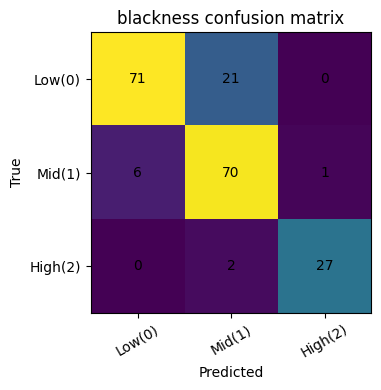


TWIST  |  Accuracy=0.5606  Macro-F1=0.5437
Confusion Matrix (rows=true, cols=pred):
 [[37 10  9]
 [20 21 30]
 [12  6 53]]

Classification Report:
              precision    recall  f1-score   support

      Low(0)     0.5362    0.6607    0.5920        56
      Mid(1)     0.5676    0.2958    0.3889        71
     High(2)     0.5761    0.7465    0.6503        71

    accuracy                         0.5606       198
   macro avg     0.5600    0.5677    0.5437       198
weighted avg     0.5618    0.5606    0.5401       198



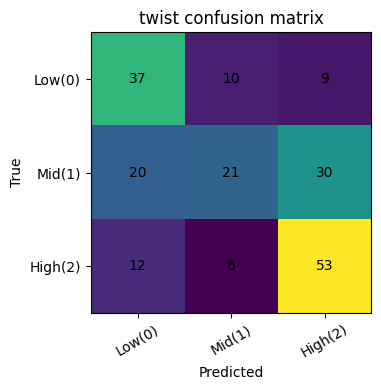


EVENNESS  |  Accuracy=0.8788  Macro-F1=0.8845
Confusion Matrix (rows=true, cols=pred):
 [[92  8  0]
 [12 54  2]
 [ 0  2 28]]

Classification Report:
              precision    recall  f1-score   support

      Low(0)     0.8846    0.9200    0.9020       100
      Mid(1)     0.8438    0.7941    0.8182        68
     High(2)     0.9333    0.9333    0.9333        30

    accuracy                         0.8788       198
   macro avg     0.8872    0.8825    0.8845       198
weighted avg     0.8780    0.8788    0.8779       198



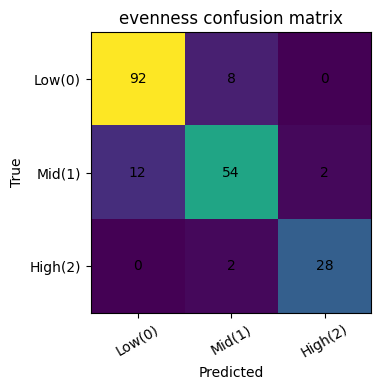


BLOOM  |  Accuracy=0.8737  Macro-F1=0.8687
Confusion Matrix (rows=true, cols=pred):
 [[27  5  0]
 [ 2 53 12]
 [ 0  6 93]]

Classification Report:
              precision    recall  f1-score   support

      Low(0)     0.9310    0.8438    0.8852        32
      Mid(1)     0.8281    0.7910    0.8092        67
     High(2)     0.8857    0.9394    0.9118        99

    accuracy                         0.8737       198
   macro avg     0.8816    0.8581    0.8687       198
weighted avg     0.8736    0.8737    0.8728       198



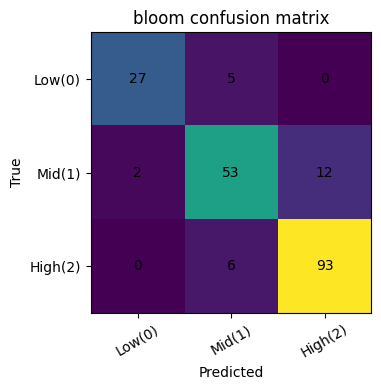


CLEANLINESS  |  Accuracy=0.8838  Macro-F1=0.8691
Confusion Matrix (rows=true, cols=pred):
 [[92  4  0]
 [ 9 56  2]
 [ 0  8 27]]

Classification Report:
              precision    recall  f1-score   support

      Low(0)     0.9109    0.9583    0.9340        96
      Mid(1)     0.8235    0.8358    0.8296        67
     High(2)     0.9310    0.7714    0.8438        35

    accuracy                         0.8838       198
   macro avg     0.8885    0.8552    0.8691       198
weighted avg     0.8849    0.8838    0.8827       198



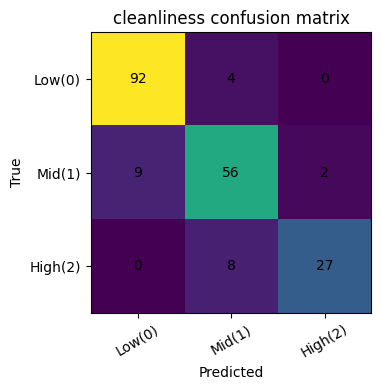

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

heads = ["blackness","twist","evenness","bloom","cleanliness"]
class_names = ["Low(0)", "Mid(1)", "High(2)"]

# ---- collect y_true from test_ds ----
y_true = {h: [] for h in heads}
for _, batch_labels in test_ds:
    for h in heads:
        y_true[h].extend(batch_labels[h].numpy().tolist())

# ---- predict ----
pred_probs = model.predict(test_ds, verbose=0)

# if model outputs dict, convert to list in correct order
if isinstance(pred_probs, dict):
    pred_probs = [pred_probs[h] for h in heads]

y_pred = {h: np.argmax(probs, axis=1) for h, probs in zip(heads, pred_probs)}

# ---- print metrics + show confusion matrix ----
for h in heads:
    yt = np.array(y_true[h])
    yp = np.array(y_pred[h])

    acc = accuracy_score(yt, yp)
    f1m = f1_score(yt, yp, average="macro")

    print("\n" + "="*70)
    print(f"{h.upper()}  |  Accuracy={acc:.4f}  Macro-F1={f1m:.4f}")
    print("="*70)

    cm = confusion_matrix(yt, yp, labels=[0,1,2])
    print("Confusion Matrix (rows=true, cols=pred):\n", cm)

    # optional: detailed report (comment out if you want shorter output)
    print("\nClassification Report:")
    print(classification_report(yt, yp, target_names=class_names, digits=4))

    # ---- plot nicely ----
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{h} confusion matrix")
    plt.xticks([0,1,2], class_names, rotation=30)
    plt.yticks([0,1,2], class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # write counts on cells
    for i in range(3):
        for j in range(3):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


# **Test on NEW images (upload and predict)**

In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
import json, os

heads = ["blackness","twist","evenness","bloom","cleanliness"]

# Load saved config bins
with open(os.path.join(MODEL_DIR, "config.json"), "r") as f:
    cfg = json.load(f)
bins = cfg["label_bins_qcut_edges"]

def preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (cfg["IMG_SIZE"], cfg["IMG_SIZE"]))
    img = tf.cast(img, tf.float32) / 255.0
    return img[None, ...]  # add batch dim

def label_to_text(v):
    return ["Low (0)", "Medium (1)", "High (2)"][int(v)]

print("Upload a test image now...")
uploaded = files.upload()

for fn in uploaded.keys():
    path = "/content/" + fn
    x = preprocess_image(path)

    out = model.predict(x, verbose=0)

    # If output is dict:
    if isinstance(out, dict):
        probs_list = [out[h] for h in heads]
    else:
        probs_list = out

    preds = {h: int(np.argmax(probs_list[i], axis=1)[0]) for i, h in enumerate(heads)}
    confs = {h: float(np.max(probs_list[i], axis=1)[0]) for i, h in enumerate(heads)}

    print("\n========================")
    print("Image:", fn)
    print("========================")
    for h in heads:
        print(f"{h:12s} -> {label_to_text(preds[h])} | confidence={confs[h]:.3f}")


In [ ]:
from google.colab import files
from google.colab import drive
import tensorflow as tf
import numpy as np
import json, os

# 1) Mount Google Drive
drive.mount("/content/drive")

# 2) Point to the folder on Drive that contains config.json
MODEL_DIR = "/content/drive/MyDrive/Research data/TeaSensoryNet_20260105_163048"  # <-- CHANGE THIS

# 3) Load config
with open(os.path.join(MODEL_DIR, "config.json"), "r") as f:
    cfg = json.load(f)

heads = ["blackness","twist","evenness","bloom","cleanliness"]
bins = cfg.get("label_bins_qcut_edges", None)  # optional (not used in your printing)

# 4) Load model (choose ONE of these approaches)

# Option A: if you saved as a single file: model.keras or model.h5
MODEL_FILE = os.path.join(MODEL_DIR, "model.keras")  # or "model.h5"
if os.path.exists(MODEL_FILE):
    model = tf.keras.models.load_model(MODEL_FILE)
else:
    # Option B: if you saved as a SavedModel folder
    # e.g. MODEL_DIR has subfolder "saved_model"
    SAVEDMODEL_DIR = os.path.join(MODEL_DIR, "saved_model")
    model = tf.keras.models.load_model(SAVEDMODEL_DIR)

def preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (int(cfg["IMG_SIZE"]), int(cfg["IMG_SIZE"])))
    img = tf.cast(img, tf.float32) / 255.0
    return img[None, ...]  # batch dimension

def label_to_text(v):
    return ["Low (0)", "Medium (1)", "High (2)"][int(v)]

print("Upload a test image now...")
uploaded = files.upload()

for fn in uploaded.keys():
    path = "/content/" + fn
    x = preprocess_image(path)

    out = model.predict(x, verbose=0)

    # If output is dict (multi-head named outputs):
    if isinstance(out, dict):
        probs_list = [out[h] for h in heads]
    else:
        probs_list = out  # list of outputs

    preds = {h: int(np.argmax(probs_list[i], axis=1)[0]) for i, h in enumerate(heads)}
    confs = {h: float(np.max(probs_list[i], axis=1)[0]) for i, h in enumerate(heads)}

    print("\n========================")
    print("Image:", fn)
    print("========================")
    for h in heads:
        print(f"{h:12s} -> {label_to_text(preds[h])} | confidence={confs[h]:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload a test image now...


Saving 25_37_CT 378 A_05.jpg to 25_37_CT 378 A_05.jpg

Image: 25_37_CT 378 A_05.jpg
blackness    -> Medium (1) | confidence=0.829
twist        -> High (2) | confidence=0.634
evenness     -> High (2) | confidence=0.807
bloom        -> Low (0) | confidence=0.926
cleanliness  -> High (2) | confidence=0.905
